<a href="https://colab.research.google.com/github/Chanoknan-P/how-to-select-variables-robustly-in-a-scoring-model/blob/main/PROJECT_DATA_MINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np #ใช้สำหรับคำนวณตัวเลขและจัดการข้อมูลจำนวนมาก
import pandas as pd #ใช้จัดการข้อมูลเป็นตาราง

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/project data mining/ref/credit_risk_dataset.csv')
df.head()     #เปิดไฟล์และดูตัวอย่างข้อมูล 5 แถวแรก

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# เรียกดู missing value
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
# ดู column
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
# กำหนดตัวแปร
continuous_vars = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
categorical_vars = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

target = "loan_status"

In [ ]:
# จัดการกับ outlier ในตัวแปรต่อเนื่องโดยใช้วิธี IQR
for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # จำกัดค่าผิดปกติไม่ให้สูงหรือต่ำเกินไป โดยไม่ลบทิ้ง
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# แสดงข้อมูลสถิติเชิงพรรณนาอีกครั้งเพื่อดูผลลัพธ์หลังจากจัดการ outlier
df[continuous_vars].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,32581.000000,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000
mean,27.440625,62419.212793,4.701461,9407.679322,11.011588,0.168808,5.705779
std,5.271083,31810.265995,3.768101,5813.035232,3.240090,0.102361,3.710454
min,20.000000,4000.000000,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,38500.000000,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,79200.000000,7.000000,12200.000000,13.470000,0.230000,8.000000
max,40.500000,140250.000000,14.500000,23000.000000,21.825000,0.440000,15.500000


In [ ]:
# จัดการ missing value ใน continuous variables
for col in continuous_vars:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


บทความที่ 2 Building Robust Credit Scoring Models with Python

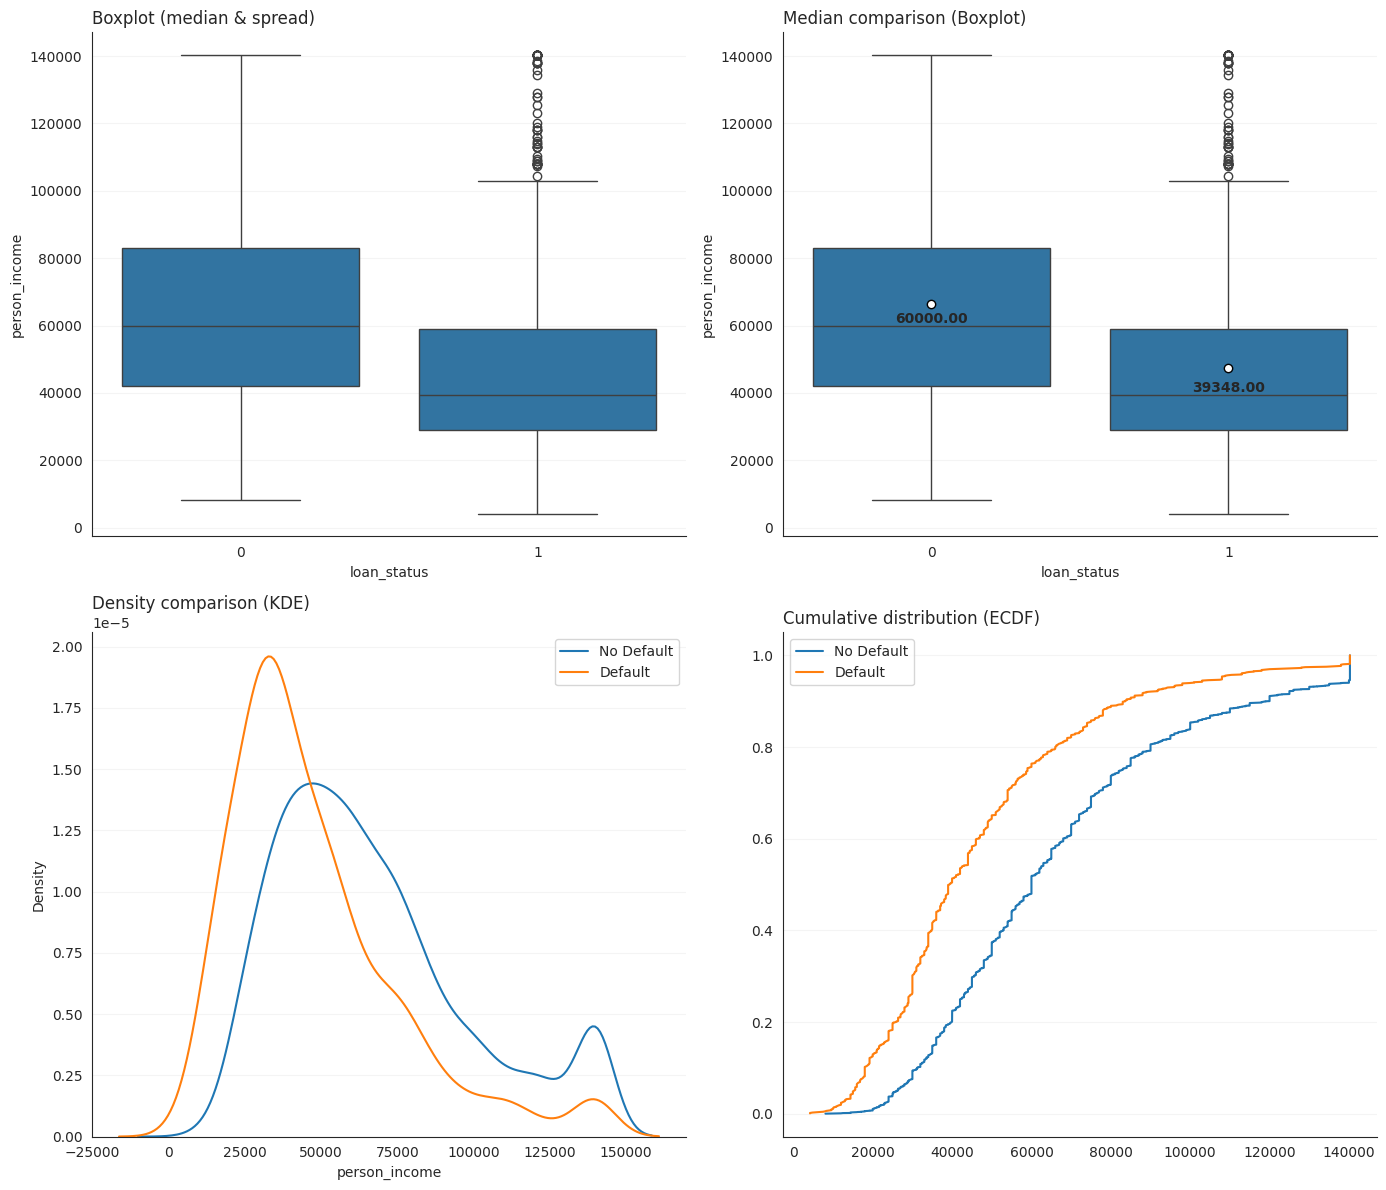

In [ ]:
# เปรียบเทียบ continuous variable กับ categorical variable
import matplotlib.pyplot as plt      #สร้างกราฟจากข้อมูล
import seaborn as sns                 #สร้างกราฟสำหรับวิเคราะห์ข้อมูลได้ง่ายและดูการกระจายของข้อมูล

def plot_continuous_vs_categorical(
    df,
    continuous_var,
    categorical_var,
    category_labels=None,
    figsize=(12, 10),
    sample=None
):
    """
    เปรียบเทียบตัวแปรที่เป็นตัวเลข ระหว่างกลุ่มต่าง ๆ โดยใช้ boxplot, KDE, and ECDFแบบ
    และจัดกราฟเป็นช่อง 2×2
    """

    sns.set_style("white")

    data = df[[continuous_var, categorical_var]].dropna().copy()

    # การสุ่มเลือกข้อมูล
    if sample:
        data = data.sample(sample, random_state=42)

    categories = sorted(data[categorical_var].unique())

    # การเปลี่ยนชื่อ labels
    if category_labels:
        labels = [category_labels.get(cat, str(cat)) for cat in categories]
    else:
        labels = [str(cat) for cat in categories]

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # 1. Boxplot
    sns.boxplot(
        data=data,
        x=categorical_var,
        y=continuous_var,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Boxplot (median & spread)", loc="left")

    #  2. Boxplot สำหรับเปรียบเทียบค่ามัธยฐาน
    sns.boxplot(
        data=data,
        x=categorical_var,
        y=continuous_var,
        ax=axes[0, 1],
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 6
        }
    )

    axes[0, 1].set_title("Median comparison (Boxplot)", loc="left")
    medians = data.groupby(categorical_var)[continuous_var].median()

    for i, cat in enumerate(categories):
        axes[0, 1].text(
            i,
            medians[cat],
            f"{medians[cat]:.2f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    #  3.  KDE กราฟเส้นโค้งที่แสดงการกระจายของข้อมูล
    for cat, label in zip(categories, labels):
        subset = data[data[categorical_var] == cat][continuous_var]
        sns.kdeplot(
            subset,
            ax=axes[1, 0],
            label=label
        )
    axes[1, 0].set_title("Density comparison (KDE)", loc="left")
    axes[1, 0].legend()

    #  4. ECDF
    for cat, label in zip(categories, labels):
        subset = np.sort(data[data[categorical_var] == cat][continuous_var])
        y = np.arange(1, len(subset) + 1) / len(subset)
        axes[1, 1].plot(subset, y, label=label)
    axes[1, 1].set_title("Cumulative distribution (ECDF)", loc="left")
    axes[1, 1].legend()

    # ทำเป็นรูปแบบกราฟที่สะอาดและเรียบง่าย
    for ax in axes.flat:
        sns.despine(ax=ax)
        ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_continuous_vs_categorical(
    df=df,
    continuous_var="person_income",
    categorical_var="loan_status",
    category_labels={0: "No Default", 1: "Default"},
    figsize=(14, 12),
    sample=5000
)

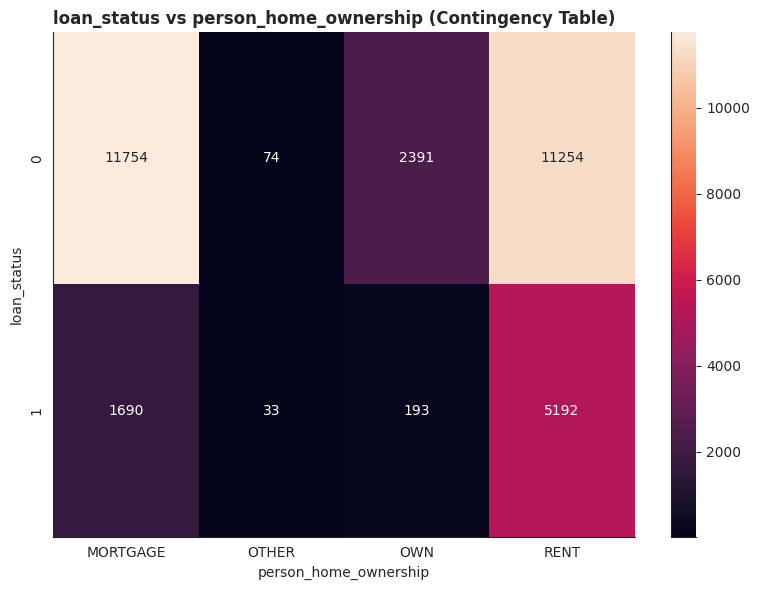

In [ ]:
# วิเคราะห์และทำความเข้าใจความสัมพันธ์ระหว่าง Categorical Variables 2 ตัว ด้วย heat map
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency #ใช้ตรวจว่า ตัวแปรประเภทกลุ่ม 2 ตัว มีความสัมพันธ์กันหรือไม่

def contingency_analysis(
    df,
    var1,
    var2,
    normalize=None,   # None, "index", "columns", "all"
    plot=True,
    figsize=(8, 6)
):
    """
   สร้างฟังก์ชันเพื่อทำคำนวณและแสดงตารางความถี่ของข้อมูล 2 ตัวแปร พร้อมทดสอบ Chi-square และคำนวณ Cramér's V

    """
    # ตารางไขว้ / ตารางความถี่
    table = pd.crosstab(df[var1], df[var2], margins=False)
    # ตารางที่แปลงจากจำนวนเป็นสัดส่วน/เปอร์เซ็นต์
    if normalize:
        table_norm = pd.crosstab(df[var1], df[var2], normalize=normalize, margins=False).round(3) * 100
    else:
        table_norm = None
    #  กราฟ Heatmap
    if plot:
        sns.set_style("white")
        plt.figure(figsize=figsize)
        data_to_plot = table_norm if table_norm is not None else table
        sns.heatmap(
            data_to_plot,
            annot=True,
            fmt=".2f" if normalize else "d",
            cbar=True
        )
        plt.title(f"{var1} vs {var2} (Contingency Table)", loc="left", weight="bold")
        plt.xlabel(var2)
        plt.ylabel(var1)
        sns.despine()
        plt.tight_layout()
        plt.show()

    # ส่ง 'loan_status' (หรือ 'def') เป็น var1 และ 'person_home_ownership' เป็น var2
contingency_analysis(df, 'loan_status', 'person_home_ownership')

ค่าที่ได้ไม่เท่ากับในเรฟเพราะจำนวนข้อมูลไม่เท่ากัน

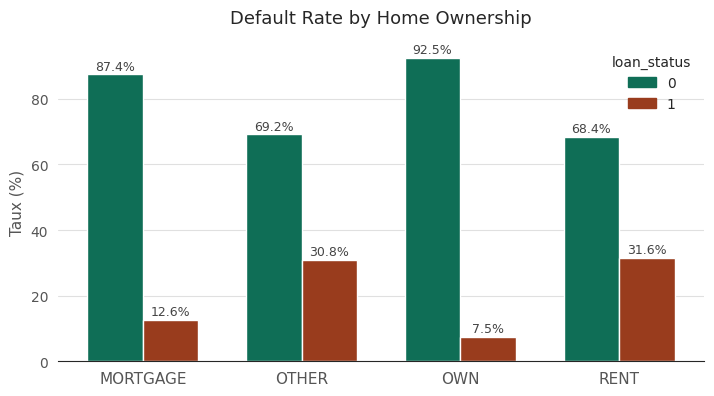

In [ ]:
# สร้างกราฟแท่งแบบจัดกลุ่ม
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches    # สร้างรูปร่างหรือสัญลักษณ์เล็ก ๆ มาใช้ในกราฟ
import pandas as pd
import numpy as np

def plot_grouped_bar(df, cat_var, subcat_var,
                          normalize="index", title=""):
    ct = pd.crosstab(df[subcat_var], df[cat_var], normalize=normalize) * 100
    modalities = ct.index.tolist()
    categories = ct.columns.tolist()
    n_mod = len(modalities)
    n_cat = len(categories)
    x = np.arange(n_mod)
    width = 0.35

    colors = ['#0F6E56', '#993C1D']  #สีเขียว = ไม่ผิดนัดชำระหนี้, สีน้ำตาล = ผิดนัดชำระหนี้

    fig, ax = plt.subplots(figsize=(7.24, 4.07), dpi=100)

    for i, (cat, color) in enumerate(zip(categories, colors)):
        offset = (i - n_cat / 2 + 0.5) * width
        ax.bar(x + offset, ct[cat], width=width, color=color, label=str(cat))

        # คำอธิบายตัวเลขกำกับด้านบนของแต่ละแท่งกราฟ
        for j, val in enumerate(ct[cat]):
            ax.text(x[j] + offset, val + 0.5, f"{val:.1f}%",
                    ha='center', va='bottom', fontsize=9, color='#444')

    # การจัดสไตล์ของกราฟ
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(modalities, fontsize=11)
    ax.set_ylabel("Taux (%)" if normalize else "Effectifs", fontsize=11, color='#555')
    ax.tick_params(left=False, colors='#555')


    handles = [mpatches.Patch(color=c, label=str(l))
               for c, l in zip(colors, categories)]
    ax.legend(handles=handles, title=cat_var, frameon=False,
              fontsize=10, loc='upper right')

    ax.set_title(title, fontsize=13, fontweight='normal', pad=14)
    plt.tight_layout()
    plt.savefig("default_by_ownership.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_grouped_bar(
    df=df,
    cat_var="loan_status",
    subcat_var="person_home_ownership",
    normalize="index",
    title="Default Rate by Home Ownership"
)

In [ ]:
# ความสัมพันธ์ระหว่างตัวแปรต่อเนื่องกับตัวแปรการผิดนัดชำระหนี้
import pandas as pd
from scipy.stats import kruskal # นำฟังก์ชัน Kruskal-Wallis test เข้ามาใช้งาน

def correlation_quanti_def_KW(database: pd.DataFrame,
                              continuous_vars: list,
                              target: str) -> pd.DataFrame:
    """
   คำนวณค่า p-value จากการทดสอบ Kruskal-Wallis ระหว่างตัวแปรเชิงต่อเนื่องกับตัวแปรเป้าหมายที่เป็นกลุ่ม (มี 2 กลุ่มหรือหลายกลุ่ม)
    ----------
    database : pd.DataFrame
        Input dataset
    continuous_vars : list
        List of continuous variable names
    target : str
        Target variable name (categorical)

    Returns
    -------
    pd.DataFrame
        ตารางที่แสดงตัวแปรแต่ละตัวพร้อมค่า p-value ที่เกี่ยวข้อง
    """

    results = []

    for var in continuous_vars:
        # ลบข้อมูลที่เป็น NA ของตัวแปรที่กำลังวิเคราะห์และตัวแปรเป้าหมายออก
        df_temp = database[[var, target]].dropna() #เปลี่ยนชื่อ df เป็น df_temp เพื่อป้องกันชื่อซ้ำ

        # แบ่งค่าของตัวแปรตามกลุ่มของตัวแปรเป้าหมาย
        groups = [
            group[var].values
            for _, group in df_temp.groupby(target)
        ]

        # Kruskal-Wallis ต้องมีอย่างน้อย 2 กลุ่มถึงจะทดสอบได้
        if len(groups) < 2:
            p_value = None
            stat = None # กำหนดค่าเริ่มต้นให้กับตัวแปร stat สำหรับกรณีนี้
        else:
            try:
                stat, p_value = kruskal(*groups)
            except ValueError:
                # จัดการกรณีที่อาจทำให้โค้ดมีปัญหา เช่น ทำให้ค่าทุกตัวเท่ากัน
                p_value = None
                stat = None # กำหนดค่าเริ่มต้นของ stat สำหรับกรณีนี้

        results.append(
            {
                "variable": var,
                "p_value": p_value,
                "stats_kw": stat
            }
        )

    return pd.DataFrame(results).sort_values(by="p_value")

continuous_vars = [
    "person_income",
    "person_age",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]
target = "loan_status" # แก้ไขชื่อของตัวแปรเป้าหมายให้ถูกต้อง
result = correlation_quanti_def_KW(
    database=df, # แก้ชื่อ DataFrame จาก database ให้เป็น df
    continuous_vars=continuous_vars,
    target=target
)

print(result)   # บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)

                     variable       p_value     stats_kw
0               person_income  0.000000e+00  2413.028966
4               loan_int_rate  0.000000e+00  2901.218157
5         loan_percent_income  0.000000e+00  3255.168393
2           person_emp_length  1.555986e-65   292.315642
3                   loan_amnt  5.447789e-52   230.179392
1                  person_age  1.585478e-09    36.426319
6  cb_person_cred_hist_length  1.715501e-05    18.481627


In [ ]:
# Correlations between qualitative variables and the default variables (Cramer's V)
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v_with_target(database: pd.DataFrame,
                          categorical_vars: list,
                          target: str) -> pd.DataFrame:
    """
   ความสัมพันธ์ระหว่างตัวแปรเชิงคุณภาพกับตัวแปรการผิดนัดชำระหนี้ (โดยใช้ Cramér's V)

    ----------
    database : pd.DataFrame
        Input dataset
    categorical_vars : list
        List of categorical variables
    target : str
        Target variable (categorical)

    Returns
    -------
    pd.DataFrame
        Table with variable, chi2 and Cramér's V
    """

    results = []

    for var in categorical_vars:
        # ลบข้อมูลที่ว่างออก
        df_temp = database[[var, target]].dropna() # เปลี่ยนชื่อ df เป็น df_temp

        # ตารางแจกแจงความถี่ หรือ ตารางที่เอาตัวแปร 2 ตัวมาเทียบกัน
        contingency_table = pd.crosstab(df_temp[var], df_temp[target])

        # ข้ามขั้นตอนนี้ไป ถ้าข้อมูลมีไม่เพียงพอ
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            results.append({
                "variable": var,
                "chi2": None,
                "cramers_v": None
            })
            continue

        try:
            chi2, _, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.values.sum()
            r, k = contingency_table.shape

            v = np.sqrt((chi2 / n) / min(k - 1, r - 1))

        except Exception:
            chi2, v = None, None

        results.append({
            "variable": var,
            "chi2": chi2,
            "cramers_v": v
        })

    result_df = pd.DataFrame(results)

    # เรียงลำดับตามความสำคัญ
    return result_df.sort_values(by="cramers_v", ascending=False)

qualitative_vars = [
    "person_home_ownership",
    "cb_person_default_on_file",
    "loan_intent",
    "loan_grade",
]
result = cramers_v_with_target(
    database=df, # แก้ไขชื่อข้อมูลจาก database ให้เป็น df
    categorical_vars=qualitative_vars,
    target=target
)

print(result)

# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

                    variable         chi2  cramers_v
3                 loan_grade  5609.184187   0.414923
0      person_home_ownership  1907.980698   0.241994
1  cb_person_default_on_file  1044.439595   0.179044
2                loan_intent   520.511561   0.126396


In [ ]:
# Multi-correlations between continuous variables (Spearman test)
import pandas as pd
def correlation_matrix_quanti(database: pd.DataFrame,
                              continuous_vars: list,
                              method: str = "spearman",
                              as_percent: bool = False) -> pd.DataFrame:
    """
    คำนวณตารางเมทริกซ์ความสัมพันธ์ของตัวแปรเชิงปริมาณ
    ----------
    database : pd.DataFrame
        Input dataset
    continuous_vars : list
        List of continuous variables
    method : str
        Correlation method ("pearson" or "spearman"), default = "spearman"
    as_percent : bool
        If True, return values in percentage

    Returns
    -------
    pd.DataFrame
        Correlation matrix
    """

    # เลือกเฉพาะข้อมูลที่เกี่ยวข้อง แล้วลบแถวที่มีค่าว่าง (NA) ออก
    df_temp = database[continuous_vars].dropna() # เปลี่ยนชื่อเป็น df_temp เพื่อไม่ให้ชื่อ df ไปทับ df ตัวหลักที่ใช้อยู่

    # ดูว่าตัวแปรตัวเลขแต่ละคู่มีความสัมพันธ์กันมากน้อยแค่ไหน
    corr_matrix = df_temp.corr(method=method)

    # เปลี่ยนค่าเป็นเปอร์เซ็นต์
    if as_percent:
        corr_matrix = corr_matrix * 100

    return corr_matrix

corr = correlation_matrix_quanti(
    database=df, # แก้ไขชื่อ database ให้เป็น df
    continuous_vars=continuous_vars,
    method="spearman"
)

print(corr)
# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

                            person_income  person_age  person_emp_length  \
person_income                    1.000000    0.144559           0.206071   
person_age                       0.144559    1.000000           0.101936   
person_emp_length                0.206071    0.101936           1.000000   
loan_amnt                        0.406280    0.064317           0.105897   
loan_int_rate                   -0.032017    0.011237          -0.063446   
loan_percent_income             -0.366433   -0.057962          -0.056453   
cb_person_cred_hist_length       0.091469    0.805443           0.065882   

                            loan_amnt  loan_int_rate  loan_percent_income  \
person_income                0.406280      -0.032017            -0.366433   
person_age                   0.064317       0.011237            -0.057962   
person_emp_length            0.105897      -0.063446            -0.056453   
loan_amnt                    1.000000       0.099268             0.653582   
loan_i

In [ ]:
# Multi-correlations between qualitative variables (Cramer's V)
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v_matrix(database: pd.DataFrame,
                     categorical_vars: list,
                     corrected: bool = False,
                     as_percent: bool = False) -> pd.DataFrame:
    """
   คำนวณตารางเมทริกซ์ความสัมพันธ์ด้วย Cramér's V สำหรับตัวแปรเชิงกลุ่ม

    ----------
    database : pd.DataFrame
        Input dataset
    categorical_vars : list
        List of categorical variables
    corrected : bool
        Apply bias correction (recommended)
    as_percent : bool
        Return values in percentage

    Returns
    -------
    pd.DataFrame
        Cramér's V matrix
    """

    def cramers_v(x, y):
        # ลบข้อมูลที่เป็นค่าว่าง (NA) ออก
        df_local = pd.DataFrame({"x": x, "y": y}).dropna() # เปลี่ยนชื่อเป็น df_local เพื่อไม่ให้ชื่อ df ไปทับตัวแปร df หลัก

        contingency_table = pd.crosstab(df_local["x"], df_local["y"])

        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            return np.nan

        chi2, _, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.values.sum()
        r, k = contingency_table.shape

        phi2 = chi2 / n

        if corrected:
            # ปรับค่า Cramér's V ให้เหมาะสม
            phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
            r_corr = r - ((r-1)**2) / (n-1)
            k_corr = k - ((k-1)**2) / (n-1)
            denom = min(k_corr - 1, r_corr - 1)
        else:
            denom = min(k - 1, r - 1)

        if denom <= 0:
            return np.nan

        return np.sqrt(phi2_corr / denom) if corrected else np.sqrt(phi2 / denom)

    # กำหนดค่าเริ่มต้นให้ตารางเมทริกซ์
    n = len(categorical_vars)
    matrix = pd.DataFrame(np.zeros((n, n)),
                          index=categorical_vars,
                          columns=categorical_vars)

    # เติมค่าลงในตารางเมทริกซ์
    for i, var1 in enumerate(categorical_vars):
        for j, var2 in enumerate(categorical_vars):
            if i <= j:
                value = cramers_v(database[var1], database[var2])
                matrix.loc[var1, var2] = value
                matrix.loc[var2, var1] = value

    # แปลงค่าเป็นเปอร์เซ็นต์
    if as_percent:
        matrix = matrix * 100

    return matrix
matrix = cramers_v_matrix(
    database=df, # แก้ไขชื่อ database ให้เป็น df
    categorical_vars=qualitative_vars,
)

print(matrix)
# บันทึกผลลัพธ์เป็นไฟล์ Excel (.xlsx)
# โค้ดสำหรับบันทึกผล Cramér's V เป็น Excel แต่ตอนนี้ถูกปิดไว้ เพราะหาตัวแปรบางตัวในโค้ดไม่เจอ

                           person_home_ownership  cb_person_default_on_file  \
person_home_ownership                   1.000000                   0.065420   
cb_person_default_on_file               0.065420                   0.999894   
loan_intent                             0.088229                   0.016956   
loan_grade                              0.087212                   0.632956   

                           loan_intent  loan_grade  
person_home_ownership         0.088229    0.087212  
cb_person_default_on_file     0.016956    0.632956  
loan_intent                   1.000000    0.021947  
loan_grade                    0.021947    1.000000  


บทความที่ 1 How to Select Variables Robustly in a Scoring Model

In [ ]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
df["fold"] = -1

# แบ่งข้อมูลให้แต่ละกลุ่มด้วยตัวแปรเป้าหมาย (จากต้นฉบับแบ่งข้อมูล ด้วย def + year เพราะมีมิติเวลา)
# ถ้า dataset ไม่มีมิติเวลา ให้แบ่งข้อมูล ด้วยตัวแปรเป้าหมายอย่างเดียวพอ
for fold, (_, test_idx) in enumerate(skf.split(df, df[target])):
    df.loc[test_idx, "fold"] = fold

df["fold"].value_counts() #นับจำนวนข้อมูลในแต่ละกลุ่มของคอลัมน์ fold

,count
fold,
0,8146
2,8145
1,8145
3,8145


In [ ]:
def build_folds(df, fold_col="fold", n_splits=4):

    #สร้างคู่ (train, test) จากคอลัมน์ fold คืนค่าเป็น list of dict: [{"train": df_train, "test": df_test}, ...]

    folds = []
    for f in range(n_splits):
        train_f = df[df[fold_col] != f].copy()
        test_f = df[df[fold_col] == f].copy()
        folds.append({"train": train_f, "test": test_f})
    return folds

folds = build_folds(df, fold_col="fold", n_splits=4)

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import StratifiedKFold  # หรือใช้ KFold

def build_and_save_folds(df, n_splits=5, target_col="loan_status", fold_col="fold", save_dir="folds/"):
    # 1. สร้างคอลัมน์ fold เปล่าไว้
    df = df.copy()
    df[fold_col] = -1

    # 2. แบ่ง Fold แบบ Stratified (รักษาอัตราส่วนให้เท่ากันทุก fold)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(df, df[target_col])):
        df.loc[test_idx, fold_col] = fold

    # 3. สร้างโฟลเดอร์สำหรับบันทึกไฟล์ (ถ้ายังไม่มี)
    os.makedirs(save_dir, exist_ok=True)

    # 4. บันทึกแต่ละ Fold หรือบันทึกไฟล์รวม
    df.to_csv(os.path.join(save_dir, "train_folds.csv"), index=False)
    print(f"บันทึกไฟล์เรียบร้อยที่: {os.path.join(save_dir, 'train_folds.csv')}")

    return df

In [ ]:
folds = build_and_save_folds(df, fold_col="fold", save_dir="folds/")

บันทึกไฟล์เรียบร้อยที่: folds/train_folds.csv


In [ ]:
# เลือก 2 ตัวแปรเชิงหมวดหมู่ให้ตรงตามเรฟ
final_numeric = selected_continuous # กำหนดค่า final_numeric จากผลลัพธ์การคัดเลือกตัวแปรต่อเนื่อง
final_categorical = selected_categorical # อัปเดต final_categorical จากผลลัพธ์ Rule 4 ที่ถูกต้อง
final_features = final_numeric + final_categorical

In [ ]:
folds = build_folds(df, fold_col="fold", n_splits=4)

def kruskal_test_per_var(data, var, target):
    df_ = data[[var, target]].dropna()
    groups = [g[var].values for _, g in df_.groupby(target)]
    if len(groups) < 2:
        return None
    try:
        stat, p = kruskal(*groups)
        return p
    except ValueError:
        return None

def filter_uncorrelated_with_target(folds, variables, target, pvalue_threshold=0.05):
    """
    คัดตัวแปรต่อเนื่องที่มี p-value < threshold (เกณฑ์) ในทุก fold
    """
    kept_vars = []
    detail_rows = []

    for var in variables:
        pvals = []
        for fold in folds:
            p = kruskal_test_per_var(fold["train"], var, target)
            pvals.append(p)
        detail_rows.append({"variable": var, "pvalues_per_fold": pvals})

        # ต้องผ่านทุก fold (p < เกณฑ์) และไม่มี fold ไหนคำนวณไม่ได้
        passed = all((p is not None and p < pvalue_threshold) for p in pvals)
        if passed:
            kept_vars.append(var)

    detail_df = pd.DataFrame(detail_rows)
    return kept_vars, detail_df

rule1_vars, rule1_detail = filter_uncorrelated_with_target(
    folds=folds, variables=continuous_vars, target=target, pvalue_threshold=0.05
)
print("ผ่าน Rule 1:", rule1_vars)
rule1_detail

ผ่าน Rule 1: ['person_income', 'person_age', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


,variable,pvalues_per_fold
0,person_income,"[0.0, 0.0, 0.0, 0.0]"
1,person_age,"[7.759619278738958e-06, 2.6878764367450678e-09..."
2,person_emp_length,"[3.038058707065881e-42, 5.924960114043808e-48,..."
3,loan_amnt,"[1.0175731851041602e-38, 5.417706977399137e-35..."
4,loan_int_rate,"[0.0, 0.0, 0.0, 0.0]"
5,loan_percent_income,"[0.0, 0.0, 0.0, 0.0]"
6,cb_person_cred_hist_length,"[0.005172362534832829, 2.6528704330078338e-05,..."


In [ ]:
def cramers_v(x, y):
    df_ = pd.DataFrame({"x": x, "y": y}).dropna()
    table = pd.crosstab(df_["x"], df_["y"])
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

def filter_categorical_variables(folds, cat_variables, target, low_threshold=0.10, high_threshold=0.50):
    """
    คัดตัวแปร categorical ที่ Cramér's V >=low_threshold (เกณฑ์ขั้นต่ำ) ในทุก fold
    (high_threshold (เกณฑ์ค่าสูง) ใช้แค่เป็น reference สำหรับตีความความแรง ไม่ใช้กรอง
    """
    kept_vars = []
    detail_rows = []

    for var in cat_variables:
        v_values = []
        for fold in folds:
            v = cramers_v(fold["train"][var], fold["train"][target])
            v_values.append(v)
        detail_rows.append({"variable": var, "cramers_v_per_fold": v_values})

        passed = all((v is not None and not np.isnan(v) and v >= low_threshold) for v in v_values)
        if passed:
            kept_vars.append(var)

    detail_df = pd.DataFrame(detail_rows)
    return kept_vars, detail_df

rule2_vars, rule2_detail = filter_categorical_variables(
    folds=folds, cat_variables=categorical_vars, target=target,
    low_threshold=0.13, high_threshold=0.50
)
print("ผ่าน Rule 2:", rule2_vars)
rule2_detail

ผ่าน Rule 2: ['person_home_ownership', 'loan_grade', 'cb_person_default_on_file']


,variable,cramers_v_per_fold
0,person_home_ownership,"[0.24330615942145292, 0.23723062032990466, 0.2..."
1,loan_intent,"[0.12434084014384827, 0.12626578345902129, 0.1..."
2,loan_grade,"[0.4107363298403217, 0.42677962828016003, 0.40..."
3,cb_person_default_on_file,"[0.1749920717990676, 0.18283706740443398, 0.18..."


เนื่องจากใช้ Dataset แบบเต็ม (Full Dataset) ทำให้ค่า Cramér's V ของ loan_intent เท่ากับ ~0.124 ซึ่งผ่านเกณฑ์ low_threshold (0.10) ดังนั้นจึงปรับค่า low_threshold เป็น 0.13

In [ ]:
def filter_correlated_variables_kfold(folds, variables, target, threshold=0.60):
    """
    ถ้าคู่ตัวแปรมี Spearman correlation >= threshold(เกณฑ์)ใน fold ใดก็ตาม
    ให้ตัดตัวที่สัมพันธ์กับตัวแปรเป้าหมายที่อ่อนกว่า (ดูจาก Kruskal-Wallis p-value เฉลี่ยทุก fold)
    """
    variables = list(variables)
    to_drop = set()

    # เตรียม p-value เฉลี่ยของแต่ละตัวแปรกับตัวแปรเป้าหมาย (ยิ่งน้อยยิ่งสัมพันธ์แรง)
    avg_pvalues = {}
    for var in variables:
        pvals = [kruskal_test_per_var(f["train"], var, target) for f in folds]
        pvals = [p for p in pvals if p is not None]
        avg_pvalues[var] = np.mean(pvals) if pvals else np.inf

    # เช็คทุก fold ทุกคู่ตัวแปร
    for fold in folds:
        corr = fold["train"][variables].corr(method="spearman").abs()
        for i in range(len(variables)):
            for j in range(i + 1, len(variables)):
                v1, v2 = variables[i], variables[j]
                if v1 in to_drop or v2 in to_drop:
                    continue
                if corr.loc[v1, v2] >= threshold:
                    # ตัดตัวที่ p-value เฉลี่ยแย่กว่า (ค่าที่มากกว่า) ทิ้ง
                    drop_var = v1 if avg_pvalues[v1] > avg_pvalues[v2] else v2
                    to_drop.add(drop_var)

    selected = [v for v in variables if v not in to_drop]
    return selected, sorted(to_drop)

selected_continuous, dropped_continuous = filter_correlated_variables_kfold(
    folds=folds, variables=rule1_vars, target=target, threshold=0.60
)
print("ตัวแปรต่อเนื่องที่เหลือ:", selected_continuous)
print("ตัดทิ้ง (ซ้ำซ้อน):", dropped_continuous)

ตัวแปรต่อเนื่องที่เหลือ: ['person_income', 'person_age', 'person_emp_length', 'loan_int_rate', 'loan_percent_income']
ตัดทิ้ง (ซ้ำซ้อน): ['cb_person_cred_hist_length', 'loan_amnt']


In [ ]:
def filter_correlated_categorical_variables(folds, cat_variables, target, high_threshold=0.50):
    """
    ถ้าคู่ตัวแปร categorical มี Cramér's V >= high_threshold (เกณฑ์ค่าสูง)ใน fold ใดก็ตาม
    ให้ตัดตัวที่สัมพันธ์กับตัวแปรเป้าหมายที่อ่อนกว่า
    """
    cat_variables = list(cat_variables)
    to_drop = set()

    avg_v_with_target = {}
    for var in cat_variables:
        v_values = [cramers_v(f["train"][var], f["train"][target]) for f in folds]
        v_values = [v for v in v_values if v is not None and not np.isnan(v)]
        avg_v_with_target[var] = np.mean(v_values) if v_values else 0

    for fold in folds:
        for i in range(len(cat_variables)):
            for j in range(i + 1, len(cat_variables)):
                v1, v2 = cat_variables[i], cat_variables[j]
                if v1 in to_drop or v2 in to_drop:
                    continue
                v_pair = cramers_v(fold["train"][v1], fold["train"][v2])
                if v_pair is not None and not np.isnan(v_pair) and v_pair >= high_threshold:
                    # ตัดตัวที่สัมพันธ์กับ target อ่อนกว่า (avg cramers_v น้อยกว่า)
                    drop_var = v1 if avg_v_with_target[v1] < avg_v_with_target[v2] else v2
                    to_drop.add(drop_var)

    selected = [v for v in cat_variables if v not in to_drop]
    return selected, sorted(to_drop)

selected_categorical, dropped_categorical = filter_correlated_categorical_variables(
    folds=folds, cat_variables=rule2_vars, target=target, high_threshold=0.50
)
print("ตัวแปร categorical ที่เหลือ:", selected_categorical)
print("ตัดทิ้ง (ซ้ำซ้อน):", dropped_categorical)

ตัวแปร categorical ที่เหลือ: ['person_home_ownership', 'loan_grade']
ตัดทิ้ง (ซ้ำซ้อน): ['cb_person_default_on_file']


In [ ]:
final_variables = selected_continuous + selected_categorical

print("=" * 50)
print(f"เริ่มต้น: {len(continuous_vars)} ตัวแปรต่อเนื่อง + {len(categorical_vars)} ตัวแปร categorical")
print(f"ผ่าน Rule 1 (Kruskal-Wallis, ทุก fold): {len(rule1_vars)} ตัว")
print(f"ผ่าน Rule 2 (Cramér's V vs target, ทุก fold): {len(rule2_vars)} ตัว")
print(f"หลัง Rule 3 (ตัด multicollinearity ต่อเนื่อง): {len(selected_continuous)} ตัว")
print(f"หลัง Rule 4 (ตัด multicollinearity categorical): {len(selected_categorical)} ตัว")
print("=" * 50)
print(f"ตัวแปรสุดท้าย ({len(final_variables)} ตัว):")
print(final_variables)

เริ่มต้น: 7 ตัวแปรต่อเนื่อง + 4 ตัวแปร categorical
ผ่าน Rule 1 (Kruskal-Wallis, ทุก fold): 7 ตัว
ผ่าน Rule 2 (Cramér's V vs target, ทุก fold): 3 ตัว
หลัง Rule 3 (ตัด multicollinearity ต่อเนื่อง): 5 ตัว
หลัง Rule 4 (ตัด multicollinearity categorical): 2 ตัว
ตัวแปรสุดท้าย (7 ตัว):
['person_income', 'person_age', 'person_emp_length', 'loan_int_rate', 'loan_percent_income', 'person_home_ownership', 'loan_grade']


In [ ]:
# สร้าง Dataframe สรุป Pipeline ตามเงื่อนไข Rule 1 - Rule 4
pipeline_summary = pd.DataFrame({
    "Filtering Stage": [
        "1. Numerical (Kruskal-Wallis, all folds)",
        "2. Categorical (Cramér's V vs target, all folds)",
        "3. Numerical multicollinearity (Spearman >= 0.60, any fold)",
        "4. Categorical multicollinearity (Cramér's V >= 0.50, any fold)",
    ],
    "Input Count": [len(continuous_vars), len(categorical_vars), len(rule1_vars), len(rule2_vars)],
    "Dropped Variables": [
        sorted(set(continuous_vars) - set(rule1_vars)) or "None",
        sorted(set(categorical_vars) - set(rule2_vars)) or "None",
        dropped_continuous,
        dropped_categorical,
    ],
    "Remaining Count": [len(rule1_vars), len(rule2_vars), len(selected_continuous), len(selected_categorical)],
})

final_variables = selected_continuous + selected_categorical
selected_features = final_variables + [target]
final_df = df[selected_features].copy()

In [ ]:
selected_features = [
    'person_income',
    'person_age',
    'person_emp_length',
    'loan_int_rate',
    'loan_percent_income',
    'person_home_ownership',
    'cb_person_default_on_file',  # หรือ 'loan_grade'
    'loan_status'
]

final_df = df[selected_features].copy()

destination_path = '/content/drive/MyDrive/project data mining/ref/selected_features_credit_risk.csv'
final_df.to_csv(destination_path, index=False, encoding='utf-8-sig')

print(f"บันทึกไฟล์ลง Google Drive เรียบร้อยแล้วที่: {destination_path}")

บันทึกไฟล์ลง Google Drive เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/selected_features_credit_risk.csv


In [ ]:
import os     #สำหรับจัดการไฟล์และโฟลเดอร์
import pandas as pd
import numpy as np
from scipy.stats import kruskal, chi2_contingency

# สร้างฟังก์ชันสำหรับคำนวณความสัมพันธ์ขึ้นมาใหม่ โดยคัดลอกมาจากเซลล์โค้ดก่อนหน้านี้

def correlation_quanti_def_KW(database: pd.DataFrame,
                              continuous_vars: list,
                              target: str) -> pd.DataFrame:
    results = []
    for var in continuous_vars:
        df_temp = database[[var, target]].dropna()
        groups = [
            group[var].values
            for _, group in df_temp.groupby(target)
        ]
        if len(groups) < 2:
            p_value = None
            stat = None
        else:
            try:
                stat, p_value = kruskal(*groups)
            except ValueError:
                p_value = None
                stat = None
        results.append(
            {
                "variable": var,
                "p_value": p_value,
                "stats_kw": stat
            }
        )
    return pd.DataFrame(results).sort_values(by="p_value")

def cramers_v_with_target(database: pd.DataFrame,
                          categorical_vars: list,
                          target: str) -> pd.DataFrame:
    results = []
    for var in categorical_vars:
        df_temp = database[[var, target]].dropna()
        contingency_table = pd.crosstab(df_temp[var], df_temp[target])
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            results.append({"variable": var, "chi2": None, "cramers_v": None})
            continue
        try:
            chi2, _, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.values.sum()
            r, k = contingency_table.shape
            v = np.sqrt((chi2 / n) / min(k - 1, r - 1))
        except Exception:
            chi2, v = None, None
        results.append({"variable": var, "chi2": chi2, "cramers_v": v})
    return pd.DataFrame(results).sort_values(by="cramers_v", ascending=False)

def correlation_matrix_quanti(database: pd.DataFrame,
                              continuous_vars: list,
                              method: str = "spearman",
                              as_percent: bool = False) -> pd.DataFrame:
    df_temp = database[continuous_vars].dropna()
    corr_matrix = df_temp.corr(method=method)
    if as_percent:
        corr_matrix = corr_matrix * 100
    return corr_matrix

def cramers_v_matrix(database: pd.DataFrame,
                     categorical_vars: list,
                     corrected: bool = False,
                     as_percent: bool = False) -> pd.DataFrame:
    def cramers_v_calc(x, y):
        df_local = pd.DataFrame({"x": x, "y": y}).dropna()
        contingency_table = pd.crosstab(df_local["x"], df_local["y"])
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            return np.nan
        chi2, _, _, _ = chi2_contingency(contingency_table)
        n = contingency_table.values.sum()
        r, k = contingency_table.shape
        phi2 = chi2 / n
        if corrected:
            phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
            r_corr = r - ((r-1)**2) / (n-1)
            k_corr = k - ((k-1)**2) / (n-1)
            denom = min(k_corr - 1, r_corr - 1)
        else:
            denom = min(k - 1, r - 1)
        if denom <= 0:
            return np.nan
        return np.sqrt(phi2_corr / denom) if corrected else np.sqrt(phi2 / denom)

    n = len(categorical_vars)
    matrix = pd.DataFrame(np.zeros((n, n)), index=categorical_vars, columns=categorical_vars)
    for i, var1 in enumerate(categorical_vars):
        for j, var2 in enumerate(categorical_vars):
            if i <= j:
                value = cramers_v_calc(database[var1], database[var2])
                matrix.loc[var1, var2] = value
                matrix.loc[var2, var1] = value
    if as_percent:
        matrix = matrix * 100
    return matrix

# คำนวณค่าความสัมพันธ์ใหม่อีกครั้ง

# ตรวจสอบให้แน่ใจว่าตัวแปร continuous_vars, categorical_vars, target และ df มีอยู่แล้ว
# ถ้าไม่มี อาจต้องสร้างตัวแปรเหล่านี้ใหม่ตรงนี้

kruskal_result_df = correlation_quanti_def_KW(
    database=df,
    continuous_vars=continuous_vars,
    target=target
)

cramers_v_target_df = cramers_v_with_target(
    database=df,
    categorical_vars=categorical_vars,
    target=target
)

spearman_corr_matrix = correlation_matrix_quanti(
    database=df,
    continuous_vars=continuous_vars,
    method="spearman"
)

cramers_v_matrix_df = cramers_v_matrix(
    database=df,
    categorical_vars=categorical_vars,
)

# สร้างตารางความสัมพันธ์ในรูปแบบเปอร์เซ็นต์
spearman_corr_matrix_percent = correlation_matrix_quanti(
    database=df,
    continuous_vars=continuous_vars,
    method="spearman",
    as_percent=True
)

cramers_v_matrix_df_percent = cramers_v_matrix(
    database=df,
    categorical_vars=categorical_vars,
    as_percent=True
)

#กำหนดตำแหน่งที่จะบันทึกไฟล์ แล้วบันทึกไฟล์ลงไป

base_save_path = '/content/drive/MyDrive/project data mining/ref'
os.makedirs(base_save_path, exist_ok=True)

kruskal_result_df.to_csv(os.path.join(base_save_path, 'kruskal_wallis_results.csv'), index=False, encoding='utf-8-sig')
cramers_v_target_df.to_csv(os.path.join(base_save_path, 'cramers_v_target_results.csv'), index=False, encoding='utf-8-sig')
spearman_corr_matrix.to_csv(os.path.join(base_save_path, 'spearman_correlation_matrix.csv'), index=True, encoding='utf-8-sig') # Keep index for matrix
cramers_v_matrix_df.to_csv(os.path.join(base_save_path, 'cramers_v_matrix.csv'), index=True, encoding='utf-8-sig') # Keep index for matrix

# บันทึกเป็นเปอร์เซ็นต์
spearman_corr_matrix_percent.to_csv(os.path.join(base_save_path, 'spearman_correlation_matrix_percent.csv'), index=True, encoding='utf-8-sig')
cramers_v_matrix_df_percent.to_csv(os.path.join(base_save_path, 'cramers_v_matrix_percent.csv'), index=True, encoding='utf-8-sig')


print(f"บันทึกไฟล์ Kruskal-Wallis Results เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'kruskal_wallis_results.csv')}")
print(f"บันทึกไฟล์ Cramér's V vs Target Results เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'cramers_v_target_results.csv')}")
print(f"บันทึกไฟล์ Spearman Correlation Matrix เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'spearman_correlation_matrix.csv')}")
print(f"บันทึกไฟล์ Cramér's V Matrix เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'cramers_v_matrix.csv')}")
print(f"บันทึกไฟล์ Spearman Correlation Matrix (Percent) เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'spearman_correlation_matrix_percent.csv')}")
print(f"บันทึกไฟล์ Cramér's V Matrix (Percent) เรียบร้อยแล้วที่: {os.path.join(base_save_path, 'cramers_v_matrix_percent.csv')}")

บันทึกไฟล์ Kruskal-Wallis Results เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/kruskal_wallis_results.csv
บันทึกไฟล์ Cramér's V vs Target Results เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/cramers_v_target_results.csv
บันทึกไฟล์ Spearman Correlation Matrix เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/spearman_correlation_matrix.csv
บันทึกไฟล์ Cramér's V Matrix เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/cramers_v_matrix.csv
บันทึกไฟล์ Spearman Correlation Matrix (Percent) เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/spearman_correlation_matrix_percent.csv
บันทึกไฟล์ Cramér's V Matrix (Percent) เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/cramers_v_matrix_percent.csv


In [ ]:
import os

# ตรวจสอบให้แน่ใจว่า base_save_path ถูกกำหนดไว้แล้ว
# ถ้ายังไม่ได้กำหนด ให้เอาเครื่องหมายคอมเมนต์ออก แล้วกำหนดค่าให้มัน
# base_save_path = '/content/drive/MyDrive/project data mining/ref'
os.makedirs(base_save_path, exist_ok=True)

# บันทึก DataFrame ที่ชื่อ pipeline_summary
pipeline_summary_path = os.path.join(base_save_path, 'pipeline_summary.csv')
pipeline_summary.to_csv(pipeline_summary_path, index=False, encoding='utf-8-sig')

print(f"บันทึกไฟล์ Pipeline Summary เรียบร้อยแล้วที่: {pipeline_summary_path}")

บันทึกไฟล์ Pipeline Summary เรียบร้อยแล้วที่: /content/drive/MyDrive/project data mining/ref/pipeline_summary.csv
